In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn as nn
import matplotlib.pyplot as plt

In [2]:
torch.manual_seed(42)

In [3]:
df = pd.read_csv("/Users/anandsharma/Documents/PhD/LearnML/CampusX/Datasets/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


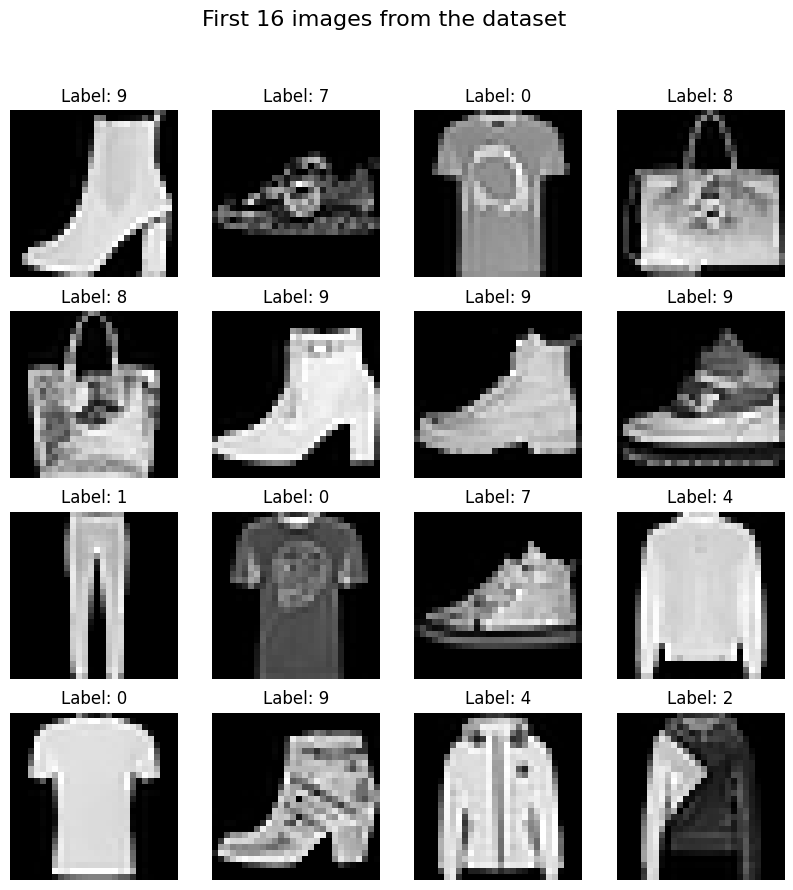

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 images from the dataset", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    image = df.iloc[i, 1:].values.reshape(28, 28)
    label = df.iloc[i, 0]
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

In [5]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Scaling the data
X_train = X_train / 255.0
X_test = X_test / 255.0

In [9]:
# Create CustomDataset class

class CustomDataset(Dataset):

    def __init__(self, features, labels): 
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


In [10]:
# Create train and test datasets objects
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [16]:
# Cretate train and test dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [17]:
class MyNN(nn.Module): 

    def __init__(self, num_features):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)        )

    def forward(self, x):
        return self.model(x)   
    

In [18]:
learning_rate = 0.1
epochs = 100 

In [19]:
model = MyNN(num_features=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [20]:
# training loop
for epoch in range(epochs):
    total_epoch_loss = 0
    for batch in train_loader:
        X_batch, y_batch = batch
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_epoch_loss/len(train_loader):.4f}")



Epoch 1/100, Loss: 1.3370
Epoch 2/100, Loss: 0.7631
Epoch 3/100, Loss: 0.6418
Epoch 4/100, Loss: 0.5697
Epoch 5/100, Loss: 0.5284
Epoch 6/100, Loss: 0.4870
Epoch 7/100, Loss: 0.4563
Epoch 8/100, Loss: 0.4383
Epoch 9/100, Loss: 0.4129
Epoch 10/100, Loss: 0.3991
Epoch 11/100, Loss: 0.3809
Epoch 12/100, Loss: 0.3620
Epoch 13/100, Loss: 0.3594
Epoch 14/100, Loss: 0.3306
Epoch 15/100, Loss: 0.3182
Epoch 16/100, Loss: 0.3062
Epoch 17/100, Loss: 0.2958
Epoch 18/100, Loss: 0.2856
Epoch 19/100, Loss: 0.2743
Epoch 20/100, Loss: 0.2644
Epoch 21/100, Loss: 0.2465
Epoch 22/100, Loss: 0.2417
Epoch 23/100, Loss: 0.2322
Epoch 24/100, Loss: 0.2267
Epoch 25/100, Loss: 0.2189
Epoch 26/100, Loss: 0.2172
Epoch 27/100, Loss: 0.2088
Epoch 28/100, Loss: 0.1948
Epoch 29/100, Loss: 0.1958
Epoch 30/100, Loss: 0.1933
Epoch 31/100, Loss: 0.1860
Epoch 32/100, Loss: 0.1788
Epoch 33/100, Loss: 0.1793
Epoch 34/100, Loss: 0.1641
Epoch 35/100, Loss: 0.1664
Epoch 36/100, Loss: 0.1593
Epoch 37/100, Loss: 0.1509
Epoch 38/1

In [21]:
model.eval()  # Set the model to evaluation mode

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [22]:
total = 0
correct = 0

with torch.no_grad():
    for batch in test_loader:
        batch_features, batch_labels = batch
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.shape[0]
        correct += (predicted == batch_labels).sum().item()
    print(f"Accuracy: {100 * correct / total:.4f}%")

Accuracy: 83.0833%
